# SN 2018ivc Radio SEDs by Epoch (Data Only)

3x3 grid: panels 1-8 show the observed SED (no model fits) at each of the 8 radio
epochs spanning the full dataset (~4 to ~2650 days post-explosion). The final panel
(bottom-right) overlays all 8 epochs on one plot. Color encodes epoch (viridis
colormap, canonical mapping per `CLAUDE_plotting.md`). As of 2026-09-01 that
canonical list is shared across wavelengths — 3 X-ray epochs (12.7, 1868.7, 2550.3
days) are interleaved into the same chronological list and color axis, so these 8
radio epochs' colors are no longer evenly spaced (they occupy 8 of 11 slots, not
8 of 8) even though this figure only plots radio data. Marker shape encodes data
source: circles are ALMA data from Maeda+2023a,b, squares are VLA data from Bill
Cotton, and stars are new data from this work (the last 5 canonical radio epochs:
1300, 1700, 2100, 2500, 2650 days). The 200-day epoch bin was widened to 150-280
days (from 150-250) to include the 263.5-day, 24.1/31.0/41.0 GHz VLA points from
Cotton.

In [1]:
import sys, os
sys.path.append(os.path.abspath(".."))

import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import functions

functions.set_plot_style()
mpl.rcParams.update({
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
})

def darken_color(color, factor=0.7):
    rgb = mcolors.to_rgb(color)
    return tuple(factor * c for c in rgb)

# --- Load data ---
data = pd.read_csv("../data/radio_18ivc_data.csv")

# --- Canonical epoch list (CLAUDE_plotting.md): full project timeline, chronological.
# The five late-time epochs (1300-2650) match the existing model-fit bins used
# elsewhere (all_sed_plot.ipynb, vlba_proposal_figures.ipynb). The three early
# epochs (4, 20, 200) are new: no model fits exist for them yet, so this figure
# shows data points only, for all 8 epochs.
# The 200-day bin is widened to 150-280 (vs. the 150-250 used for the epoch-color
# table) to pull in the 263.5-day/24.1,31.0,41.0 GHz VLA points from Cotton.
epoch_info = [
    (4.0, 0, 10),
    (20.0, 10, 30),
    (200.0, 150, 280),
    (1300.0, 1200, 1400),
    (1700.0, 1600, 1800),
    (2100.0, 2000, 2200),
    (2500.0, 2350, 2550),
    (2650.0, 2550, 2750),
]

# Epochs with new VLA monitoring data from this work (rather than literature).
# ALMA points that happen to fall in these same phase windows (e.g. the 100/250
# GHz points at ~1364 days, in the 1300.0 bin) are still literature (Maeda) data.
THIS_WORK_EPOCHS = {1300.0, 1700.0, 2100.0, 2500.0, 2650.0}

# Viridis position of each epoch in the single project-wide canonical list
# (CLAUDE_plotting.md), NOT a fresh linspace over just these 8 radio epochs.
# As of 2026-09-01 that list is 11 epochs -- 3 X-ray epochs (12.7, 1868.7, 2550.3
# days) are interleaved between these radio ones, so the 8 values here are not
# evenly spaced even though they were before that change. X-ray epochs don't
# have radio data and so don't get a panel in this figure, but they still take up
# slots in the shared color axis.
CANONICAL_X = {
    4.0: 1.000,
    20.0: 0.800,
    200.0: 0.700,
    1300.0: 0.600,
    1700.0: 0.500,
    2100.0: 0.300,
    2500.0: 0.200,
    2650.0: 0.000,
}

cmap = mpl.colormaps["viridis"]
colors = [cmap(CANONICAL_X[label]) for label, _, _ in epoch_info]

# --- Marker shape by data source ---
# ALMA (Maeda+2023a,b) -> circle always. VLA -> star if it's new monitoring
# from this work (the five late canonical epochs), otherwise square (Cotton,
# literature). VLASS -> square (archival survey data, not new monitoring).
MARKER_SIZE = {"o": 9, "s": 9, "*": 15}
SOURCE_LABEL = {
    "o": "ALMA (Maeda+2023a,b)",
    "s": "VLA (19A-219, W. Cotton)",
    "*": "VLA (This work)",
}

def marker_for(epoch_label, telescope):
    if telescope == "ALMA":
        return "o"
    if telescope == "VLA" and epoch_label in THIS_WORK_EPOCHS:
        return "*"
    return "s"

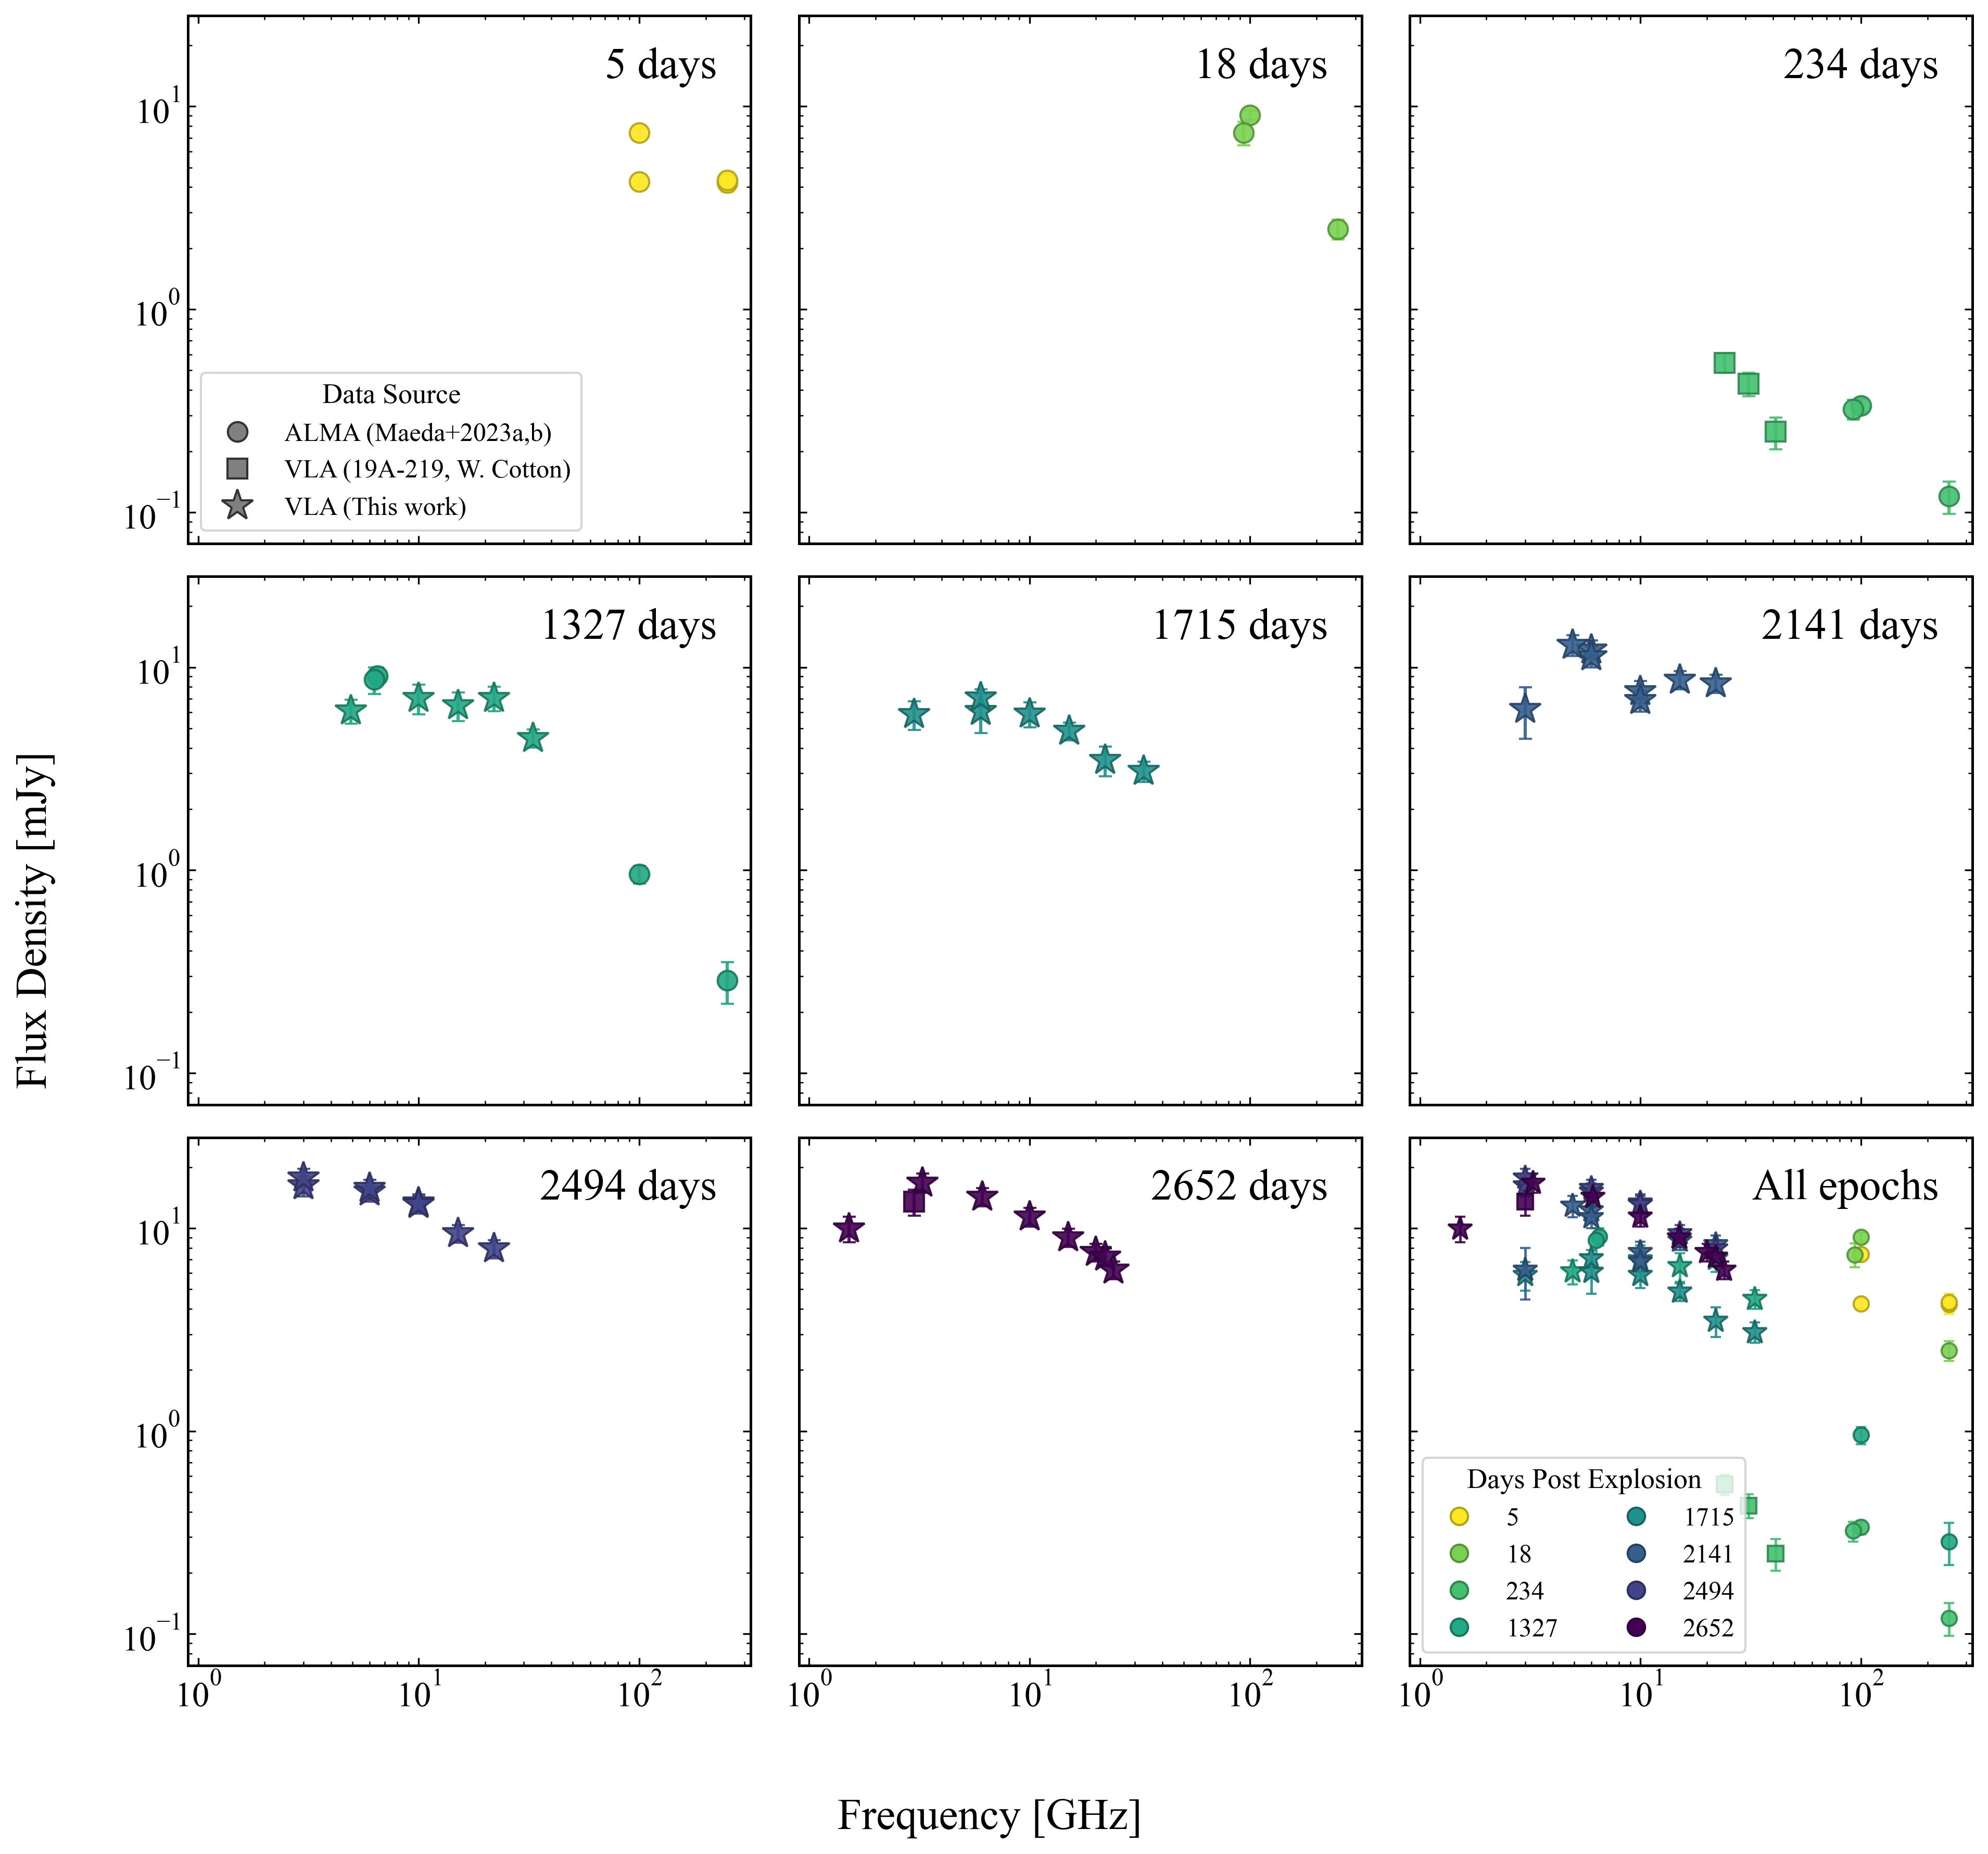

In [2]:
fig, axes = plt.subplots(3, 3, figsize=(13, 12), dpi=300, sharex=True, sharey=True)
axes = axes.flatten()

# Shared log-log limits across every panel, sized to fit the full selected dataset.
xlim = (0.9, 320)
ylim = (0.07, 28)

epoch_data = []
for (label, lo, hi), color in zip(epoch_info, colors):
    d_epoch = data[(data["phase"] >= lo) & (data["phase"] <= hi)]
    avg_phase = d_epoch["phase"].mean()
    epoch_data.append((label, avg_phase, d_epoch, color))


def plot_epoch(ax, label, d_epoch, color, ms_scale=1.0):
    """Plot one epoch's points, split by data-source marker shape."""
    edge_color = darken_color(color, 0.7)
    for telescope, d_src in d_epoch.groupby("telescope"):
        marker = marker_for(label, telescope)
        ax.errorbar(
            d_src["freq"],
            d_src["flux"],
            yerr=d_src["flux_err"],
            fmt=marker,
            ms=MARKER_SIZE[marker] * ms_scale,
            capsize=3 * ms_scale,
            elinewidth=1.5 * ms_scale,
            linestyle="none",
            color=color,
            markeredgecolor=edge_color,
            alpha=0.9,
            zorder=3,
        )


# --- Panels 1-8: one epoch per panel ---
for ax, (label, avg_phase, d_epoch, color) in zip(axes[:8], epoch_data):
    plot_epoch(ax, label, d_epoch, color)
    ax.text(
        0.94, 0.94, f"{avg_phase:.0f} days",
        transform=ax.transAxes, ha="right", va="top", fontsize=20,
    )
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)

# --- Panel 9 (bottom-right): all epochs together ---
ax_all = axes[8]
for label, avg_phase, d_epoch, color in epoch_data:
    plot_epoch(ax_all, label, d_epoch, color, ms_scale=7 / 9)
ax_all.set_xscale("log")
ax_all.set_yscale("log")
ax_all.set_xlim(*xlim)
ax_all.set_ylim(*ylim)
ax_all.text(
    0.94, 0.94, "All epochs",
    transform=ax_all.transAxes, ha="right", va="top", fontsize=20,
)

# Epoch-color legend lives in the "All epochs" panel, in its empty low-freq/
# low-flux corner (no data sits at freq <~4.5 GHz with flux <~3 mJy).
epoch_handles = [
    mpl.lines.Line2D(
        [], [], marker="o", linestyle="none", color=color,
        markeredgecolor=darken_color(color, 0.7), ms=8,
        label=f"{avg_phase:.0f}",
    )
    for label, avg_phase, d_epoch, color in epoch_data
]
ax_all.legend(
    handles=epoch_handles,
    title="Days Post Explosion", title_fontsize=13, fontsize=12,
    ncol=2, loc="lower left", frameon=True,
)

# Data-source (marker shape) legend lives in the sparse "5 days" panel instead
# (axes[0]), which otherwise has a lot of unused space, rather than crowding
# the already busy "All epochs" panel.
source_handles = [
    mpl.lines.Line2D(
        [], [], marker=marker, linestyle="none", color="0.5",
        markeredgecolor="0.2", ms=MARKER_SIZE[marker],
        label=source_label,
    )
    for marker, source_label in SOURCE_LABEL.items()
]
axes[0].legend(
    handles=source_handles,
    title="Data Source", title_fontsize=13, fontsize=12,
    loc="lower left", frameon=True,
)

# Panels share single outer axis labels rather than repeating per panel.
fig.supxlabel("Frequency [GHz]", fontsize=20)
fig.supylabel("Flux Density [mJy]", fontsize=20)

fig.tight_layout(rect=[0.02, 0.02, 1, 1])

fig.savefig("../figures/sed_epoch_grid.png", bbox_inches="tight", dpi=300)
fig.savefig("../figures/sed_epoch_grid.pdf", bbox_inches="tight")

plt.show()